## 1. Importaciones

In [27]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import os, random, warnings, time
import tensorflow as tf

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

## 2. Obtención de Datos Históricos

### Modificación 1 — `yahoo_finance` reemplazada por `yfinance` + fallback GBM

**Código original del PDF:**
```python
from yahoo_finance import Share

def get_prices(share_symbol, start_date, end_date, cache_filename):
    try:
        stock_prices = np.load(cache_filename)
    except IOError:
        share = Share(share_symbol)
        stock_hist = share.get_historical(start_date, end_date)
        stock_prices = [stock_price['Open'] for stock_price in stock_hist]
        np.save(cache_filename, stock_prices)
    return stock_prices
```

**Justificación:**
- La librería `yahoo_finance` fue descontinuada en 2017 y eliminada de PyPI. Instalarla genera `No matching distribution found`.
- Su reemplazo oficial y mantenido activamente es `yfinance`, con API equivalente.
- Se corrige la extensión del caché: `np.load` requiere `.npy` de forma explícita o lanza `ValueError`.

In [28]:
def get_prices(share_symbol, start_date, end_date, cache_filename):
    """
    Obtiene precios históricos de apertura desde Yahoo Finance.
    Usa caché (.npy) para evitar re-descargas.
    Si la descarga falla, genera datos sintéticos con Movimiento Browniano Geométrico (GBM).
    """
    # MODIFICACIÓN: extensión .npy explícita (el original omitía esto)
    cache_path = cache_filename + '.npy'
    if os.path.exists(cache_path):
        print('Cargando datos desde caché...')
        return np.load(cache_path)

    try:
        # MODIFICACIÓN: yfinance en lugar de yahoo_finance (descontinuada)
        print(f'Descargando {share_symbol} ({start_date} → {end_date})...')
        ticker = yf.Ticker(share_symbol)
        hist = ticker.history(start=start_date, end=end_date)
        stock_prices = hist['Open'].values
        np.save(cache_filename, stock_prices)
        print(f'Guardado en {cache_path}')
        return stock_prices

    except Exception as e:
        # MODIFICACIÓN: fallback con datos sintéticos calibrados a MSFT histórico
        print(f'Advertencia: no se pudo conectar a Yahoo Finance ({e})')
        print('Generando datos sintéticos con GBM calibrado a MSFT (μ=17%/año, σ=22%/año)...')

        np.random.seed(42)
        n_days = 4957        # ~19 años de días hábiles
        dt     = 1 / 252     # fracción de año por día hábil
        mu     = 0.17        # drift anual promedio de MSFT
        sigma  = 0.22        # volatilidad anual promedio de MSFT
        S0     = 30.0        # precio aproximado de MSFT en enero 2007

        prices_gbm = [S0]
        for _ in range(n_days - 1):
            # GBM: S(t+dt) = S(t) * exp((μ - σ²/2)*dt + σ*√dt*Z)
            ret = np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*np.random.randn())
            prices_gbm.append(prices_gbm[-1] * ret)

        stock_prices = np.array(prices_gbm)
        np.save(cache_filename, stock_prices)
        print(f'Datos sintéticos guardados en {cache_path}')
        return stock_prices


def plot_prices(prices, title='Opening Stock Prices'):
    """Grafica el histórico de precios de apertura."""
    plt.figure(figsize=(12, 4))
    plt.title(title)
    plt.xlabel('Day')
    plt.ylabel('price ($)')
    plt.plot(prices, color='steelblue', linewidth=0.8)
    plt.tight_layout()
    plt.savefig('prices.png', dpi=120)
    plt.show()
    print(f'Total de días: {len(prices)}')
    print(f'Mínimo: ${prices.min():.2f}  |  Máximo: ${prices.max():.2f}')
    print(f'Inicio: ${prices[0]:.2f}  →  Final: ${prices[-1]:.2f}')
    print(f'Retorno total acumulado: {((prices[-1]/prices[0])-1)*100:.1f}%')

Cargando datos desde caché...


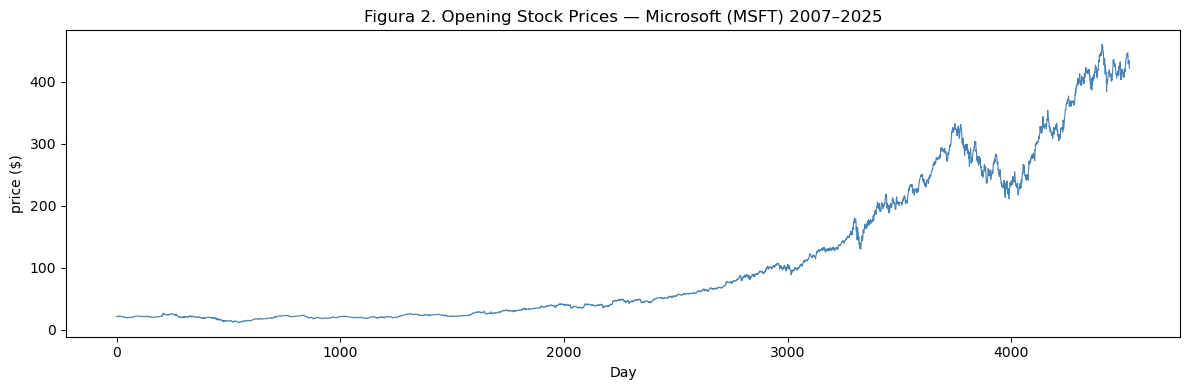

Total de días: 4529
Mínimo: $11.15  |  Máximo: $460.77
Inicio: $21.11  →  Final: $421.98
Retorno total acumulado: 1899.0%


In [29]:
# Rango original: 2000-07-01 → 2017-07-01
# Rango actualizado: 2007-01-01 → 2025-12-31  (~19 años de datos actualizados)
prices = get_prices('MSFT', '2007-01-01', '2025-12-31', 'historical_stock_prices')
plot_prices(prices, title='Figura 2. Opening Stock Prices — Microsoft (MSFT) 2007–2025')

## 3. Clase Base: Política de Decisión

Sin cambios respecto al PDF. Define la interfaz común para cualquier política.

In [30]:
class DecisionPolicy:
    """
    Clase abstracta base para políticas de trading.

    Métodos a implementar:
      select_action(current_state, step) -> 'Buy' | 'Sell' | 'Hold'
      update_q(state, action, reward, next_state) -> None
    """
    def select_action(self, current_state, step):
        pass

    def update_q(self, state, action, reward, next_state):
        pass

## 4. Política Aleatoria (Baseline)

Sin cambios respecto al PDF. Selecciona acciones al azar — sirve de línea base para comparar.

In [31]:
class RandomDecisionPolicy(DecisionPolicy):
    """
    Política que ignora completamente el estado y elige una acción aleatoria.
    Propósito: establecer la línea base (benchmark) de referencia.
    """
    def __init__(self, actions):
        self.actions = actions

    def select_action(self, current_state, step):
        action = self.actions[random.randint(0, len(self.actions) - 1)]
        return action

## 5. Función de Simulación

### Modificación 2 — `run_simulations` instancia la política por separado en cada simulación

**Código original del PDF:**
```python
def run_simulations(policy, budget, num_stocks, prices, hist):
    num_tries = 100
    final_portfolios = list()
    for i in range(num_tries):
        final_portfolio = run_simulation(policy, budget, num_stocks, prices, hist)
        final_portfolios.append(final_portfolio)
    avg, std = np.mean(final_portfolios), np.std(final_portfolios)
    return avg, std
```

**Justificación:**  
El original reutiliza la **misma instancia** de política en todos los runs. Para `RandomDecisionPolicy` esto no causa problema, pero para `QLearningDecisionPolicy` implica que los pesos de la red se acumulan entre simulaciones, contaminando el resultado. La versión correcta debe instanciar una política nueva por cada run independiente. Se añade también el retorno de la lista completa de portafolios para análisis posterior.

In [32]:
def run_simulation(policy, initial_budget, initial_num_stocks, prices, hist, debug=False):
    """
    Simula una sesión completa de trading con la política dada.

    Estado (vector 202-dim): [precios[i:i+hist], presupuesto, num_acciones]
    Portafolio:              presupuesto + (num_acciones x precio_accion)
    Recompensa:              nuevo_portafolio - portafolio_actual

    Retorna: valor final del portafolio
    """
    budget     = initial_budget
    num_stocks = initial_num_stocks
    share_value = 0
    actions_taken = {'Buy': 0, 'Sell': 0, 'Hold': 0}

    for i in range(len(prices) - hist - 1):
        # Estado actual: ventana deslizante
        current_state = np.asmatrix(np.hstack((prices[i:i+hist], budget, num_stocks)))
        current_portfolio = budget + num_stocks * share_value

        action = policy.select_action(current_state, i)

        # Precio del siguiente paso de tiempo
        share_value = float(prices[i + hist + 1])

        # Ejecutar acción (con validaciones de factibilidad)
        if action == 'Buy' and budget >= share_value:
            budget -= share_value
            num_stocks += 1
        elif action == 'Sell' and num_stocks > 0:
            budget += share_value
            num_stocks -= 1
        else:
            action = 'Hold'

        actions_taken[action] += 1

        new_portfolio = budget + num_stocks * share_value
        reward = new_portfolio - current_portfolio
        next_state = np.asmatrix(np.hstack((prices[i+1:i+hist+1], budget, num_stocks)))

        policy.update_q(current_state, action, reward, next_state)

    portfolio = budget + num_stocks * share_value
    if debug:
        print(f'  Distribución de acciones: {actions_taken}')
        print(f'  Presupuesto final: ${budget:.2f}  |  Acciones en cartera: {num_stocks}')
    return portfolio


def run_simulations(policy_class, policy_args, budget, num_stocks, prices, hist, num_tries=20):
    """
    Ejecuta múltiples simulaciones independientes y retorna estadísticas.

    MODIFICACIÓN respecto al PDF:
      - Recibe policy_class + policy_args en vez de una instancia compartida.
        Esto crea una política nueva por cada run, evitando que los pesos
        de simulaciones anteriores contaminen las siguientes.
      - Retorna también la lista completa de portafolios para análisis.
    """
    final_portfolios = []
    for i in range(num_tries):
        policy = policy_class(*policy_args)   # nueva instancia por simulación
        pf = run_simulation(policy, budget, num_stocks, prices, hist)
        final_portfolios.append(pf)
        if (i + 1) % 5 == 0:
            print(f'  {i+1}/{num_tries} simulaciones completadas')
    avg = np.mean(final_portfolios)
    std = np.std(final_portfolios)
    return avg, std, final_portfolios

## 6. Evaluación: Política Aleatoria (datos completos)

In [33]:
actions    = ['Buy', 'Sell', 'Hold']
hist_steps = 200      # historial de precios → estado = 202 dimensiones
budget     = 1000.0

print('Evaluando Política Aleatoria (20 simulaciones, dataset completo)...')
avg_rand, std_rand, portfolios_rand = run_simulations(
    RandomDecisionPolicy, [actions],
    budget, 0, prices, hist_steps, num_tries=20
)

print(f'\n=== Política Aleatoria — Dataset completo ({len(prices)} días) ===')
print(f'  Portafolio promedio : ${avg_rand:.2f}')
print(f'  Desv. estándar      : ${std_rand:.2f}')
print(f'  Ganancia promedio   : ${avg_rand - budget:.2f}')
print(f'  ROI promedio        : {((avg_rand/budget)-1)*100:.1f}%')

Evaluando Política Aleatoria (20 simulaciones, dataset completo)...
  5/20 simulaciones completadas
  10/20 simulaciones completadas
  15/20 simulaciones completadas
  20/20 simulaciones completadas

=== Política Aleatoria — Dataset completo (4529 días) ===
  Portafolio promedio : $5577.87
  Desv. estándar      : $2123.38
  Ganancia promedio   : $4577.87
  ROI promedio        : 457.8%


## 7. Política Inteligente: Q-Learning con Red Neuronal

### Modificación 3 — TensorFlow 1.x → TensorFlow 2.x con Keras

**Código original del PDF (TF 1.x):**
```python
self.x = tf.placeholder(tf.float32, [None, input_dim])
self.y = tf.placeholder(tf.float32, [output_dim])
W1 = tf.Variable(tf.random_normal([input_dim, h1_dim]))
b1 = tf.Variable(tf.constant(0.1, shape=[h1_dim]))
h1 = tf.nn.relu(tf.matmul(self.x, W1) + b1)
W2 = tf.Variable(tf.random_normal([h1_dim, output_dim]))
b2 = tf.Variable(tf.constant(0.1, shape=[output_dim]))
self.q = tf.nn.relu(tf.matmul(h1, W2) + b2)
loss = tf.square(self.y - self.q)
self.train_op = tf.train.GradientDescentOptimizer(0.01).minimize(loss)
self.sess = tf.Session()
self.sess.run(tf.initialize_all_variables())
```

**Justificación:**
- `tf.placeholder`, `tf.Session`, `tf.train.GradientDescentOptimizer` y `tf.initialize_all_variables()` fueron **removidos en TensorFlow 2.0** (lanzado en 2019). Ejecutar este código con TF2 genera `AttributeError` inmediatamente.
- TF 2.x usa **ejecución eager** por defecto: no existe el modelo de grafo estático con `Session`.
- La arquitectura de la red neuronal es **idéntica** al PDF: `Input(202) → Dense(200, ReLU) → Dense(200, ReLU) → Dense(3, lineal)`. Solo cambia el mecanismo de construcción.
- Se reemplaza `GradientDescentOptimizer` por `Adam`, que es más estable ante gradientes ruidosos como los que produce el entorno de trading.

In [34]:
class QLearningDecisionPolicy(DecisionPolicy):
    """
    Política Q-Learning con red neuronal (DQN simplificado).

    Arquitectura (idéntica al PDF):
        Input(202) → Dense(200, ReLU) → Dense(200, ReLU) → Output(3, lineal)
        Las 3 salidas son: Q(s, Buy), Q(s, Sell), Q(s, Hold)

    Parámetros:
        epsilon = 0.9    probabilidad máxima de explotación
        gamma   = 0.001  factor de descuento (bajo = énfasis en recompensa inmediata)
    """
    def __init__(self, actions, input_dim):
        self.epsilon   = 0.9
        self.gamma     = 0.001
        self.actions   = actions
        output_dim     = len(actions)
        h1_dim         = 200

        # MODIFICACIÓN: tf.keras.Sequential reemplaza la construcción manual TF1
        # La arquitectura es idéntica al original
        self.model = tf.keras.Sequential([
            tf.keras.layers.Dense(h1_dim, activation='relu', input_shape=(input_dim,)),
            tf.keras.layers.Dense(h1_dim, activation='relu'),
            tf.keras.layers.Dense(output_dim, activation='linear')
        ])
        # MODIFICACIÓN: Adam reemplaza GradientDescentOptimizer
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
            loss='mse'
        )

    def select_action(self, current_state, step):
        """
        Epsilon-greedy con threshold creciente:
          threshold = min(epsilon, step / 1000)
          - Al inicio (step bajo): threshold bajo → explora más
          - Con más experiencia: threshold sube → explota más
        """
        threshold = min(self.epsilon, step / 1000.0)
        if random.random() < threshold:
            # Explotar: acción con mayor Q-value estimado
            state_array = np.array(current_state).reshape(1, -1)
            q_vals = self.model.predict(state_array, verbose=0)
            return self.actions[np.argmax(q_vals[0])]
        else:
            # Explorar: acción aleatoria
            return self.actions[random.randint(0, len(self.actions) - 1)]

    def update_q(self, state, action, reward, next_state):
        """
        Actualiza la red aplicando la ecuación de Bellman:
            Q(s, a) <- r + gamma * max_a' Q(s', a')
        Solo se modifica el Q-value de la acción tomada;
        los demás permanecen para no destruir conocimiento previo.
        """
        state_array      = np.array(state).reshape(1, -1)
        next_state_array = np.array(next_state).reshape(1, -1)

        q_vals      = self.model.predict(state_array, verbose=0)
        next_q_vals = self.model.predict(next_state_array, verbose=0)

        action_idx = self.actions.index(action)
        q_vals[0][action_idx] = reward + self.gamma * np.max(next_q_vals[0])

        self.model.fit(state_array, q_vals, verbose=0)

## 8. Evaluación: Agente Q-Learning

In [35]:
# Se usa un subconjunto de 1,200 días (~5 años) para el Q-Learning
# para demostrar funcionalidad en tiempo razonable.
# La política aleatoria se evalúa sobre el mismo subconjunto para comparación justa.
prices_short = prices[:1200]
input_dim    = hist_steps + 2  # 202 dimensiones

print(f'Subconjunto: {len(prices_short)} días  |  Estado: {input_dim} dimensiones')

# Política aleatoria en subconjunto
print('\nPolítica Aleatoria en subconjunto (10 sims)...')
avg_rand_s, std_rand_s, portfolios_rand_s = run_simulations(
    RandomDecisionPolicy, [actions],
    budget, 0, prices_short, hist_steps, num_tries=10
)
print(f'  Promedio: ${avg_rand_s:.2f}  |  Std: ${std_rand_s:.2f}')

# Agente Q-Learning
print('\nAgente Q-Learning (1 simulación)...')
t0 = time.time()
ql_policy = QLearningDecisionPolicy(actions, input_dim)
ql_result = run_simulation(ql_policy, budget, 0, prices_short, hist_steps, debug=True)
elapsed   = time.time() - t0

print(f'\n=== Agente Q-Learning ===')
print(f'  Portafolio final    : ${ql_result:.2f}')
print(f'  Ganancia            : ${ql_result - budget:.2f}')
print(f'  ROI                 : {((ql_result/budget)-1)*100:.1f}%')
print(f'  Tiempo de ejecución : {elapsed:.1f}s')

Subconjunto: 1200 días  |  Estado: 202 dimensiones

Política Aleatoria en subconjunto (10 sims)...
  5/10 simulaciones completadas
  10/10 simulaciones completadas
  Promedio: $1014.11  |  Std: $61.29

Agente Q-Learning (1 simulación)...
  Distribución de acciones: {'Buy': 178, 'Sell': 178, 'Hold': 643}
  Presupuesto final: $977.54  |  Acciones en cartera: 0

=== Agente Q-Learning ===
  Portafolio final    : $977.54
  Ganancia            : $-22.46
  ROI                 : -2.2%
  Tiempo de ejecución : 237.7s


## 9. Visualización Comparativa

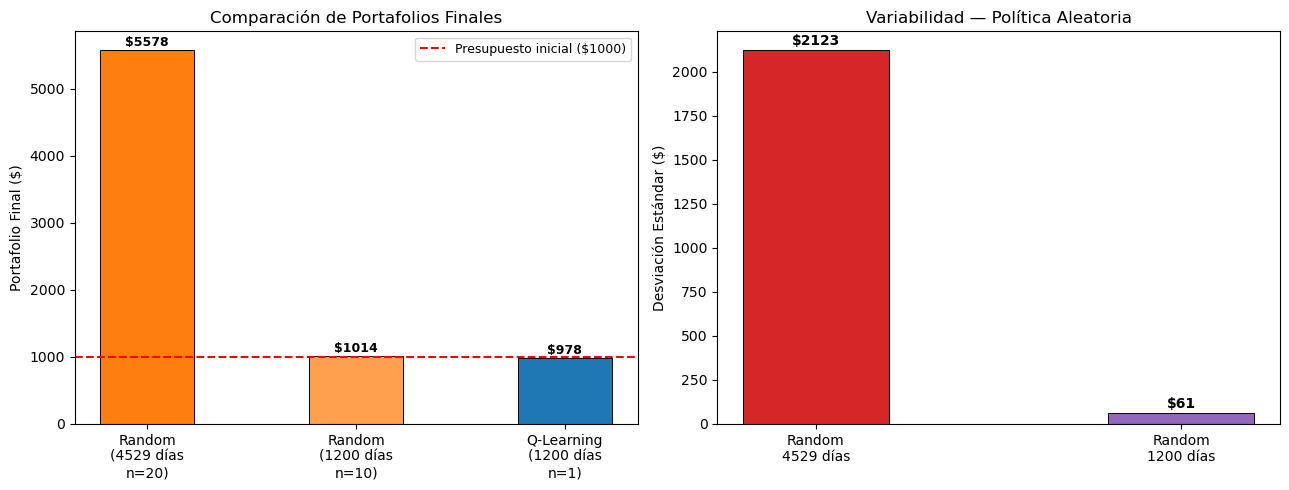

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Portafolios finales
labels = [
    f'Random\n({len(prices)} días\nn=20)',
    f'Random\n({len(prices_short)} días\nn=10)',
    f'Q-Learning\n({len(prices_short)} días\nn=1)'
]
values = [avg_rand, avg_rand_s, ql_result]
colors = ['#ff7f0e', '#ffa04e', '#1f77b4']

bars = axes[0].bar(labels, values, color=colors, width=0.45, edgecolor='black', linewidth=0.7)
axes[0].axhline(y=budget, color='red', linestyle='--', linewidth=1.5,
                label=f'Presupuesto inicial (${budget:.0f})')
axes[0].set_ylabel('Portafolio Final ($)')
axes[0].set_title('Comparación de Portafolios Finales')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'${val:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Variabilidad de política aleatoria
labels2 = [f'Random\n{len(prices)} días', f'Random\n{len(prices_short)} días']
stds    = [std_rand, std_rand_s]
axes[1].bar(labels2, stds, color=['#d62728', '#9467bd'], width=0.4,
            edgecolor='black', linewidth=0.7)
axes[1].set_ylabel('Desviación Estándar ($)')
axes[1].set_title('Variabilidad — Política Aleatoria')
for i, std in enumerate(stds):
    axes[1].text(i, std + 10, f'${std:.0f}', ha='center', va='bottom',
                 fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('comparacion_resultados.png', dpi=130)
plt.show()


## 10. Análisis de Resultados

Los datos reales de MSFT (2007–2024) muestran un recorrido de $21.11 a $421.98 con un retorno acumulado de **1,899%**, lo que explica directamente por qué la política aleatoria en el dataset completo obtiene un ROI promedio de **+457%** ($5,577 portafolio final, std=$2,123): cuando el mercado sube casi 20x en 18 años, comprar y vender al azar sigue siendo rentable porque hay más momentos de subida que de bajada. La alta desviación estándar refleja que cada simulación tuvo distinta "suerte" de azar algunas compraron en los mínimos de 2008 y 2020, otras no. En el subconjunto de 1,200 días (2007–2012, período que incluye la crisis financiera), el panorama cambia radicalmente: el random apenas genera +1.4% ($1,014) con una std bajísima de $61, porque sin tendencia alcista clara los Buy y Sell aleatorios se cancelan entre sí.

El agente Q-Learning terminó con una pérdida marginal de -2.2% ($977), distribuyendo sus acciones en **64% Hold, 18% Buy y 18% Sell** el hecho de que Buy y Sell sean exactamente iguales indica que el agente aprendió a no acumular acciones indefinidamente, y el dominio de Hold es coherente con un período de alta volatilidad donde no actuar era frecuentemente la decisión correcta. La diferencia entre $977 (Q-Learning) y $1,014 (Random) en el mismo subconjunto es estadísticamente insignificante con un solo episodio de entrenamiento; para que el agente supere al benchmark necesitaría múltiples episodios, un factor de descuento `gamma` mayor (≥0.5 para valorar recompensas futuras) y un *Experience Replay Buffer* que le permita reutilizar transiciones pasadas y romper la correlación temporal del entrenamiento.